In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Загрузка данных
df = pd.read_csv('features_3_sec.csv')

# Удаляем неинформативные признаки
X = df.drop(['filename', 'label'], axis=1)
y = df['label'].map({'blues': 0, 'classical': 1,'country': 2, 'disco': 3,'hiphop': 4, 'jazz': 5,'metal': 6, 'pop': 7,'reggae': 8, 'rock': 9})  

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабирование признаков (критично для KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Проверка дисперсии
variances = np.var(X_train_scaled, axis=0)
zero_var_features = np.where(variances == 0)[0]

if len(zero_var_features) > 0:
    print(f"Удаляем признаки с нулевой дисперсией: {zero_var_features}")
    X_train_scaled = np.delete(X_train_scaled, zero_var_features, axis=1)
    X_test_scaled = np.delete(X_test_scaled, zero_var_features, axis=1)

Удаляем признаки с нулевой дисперсией: [0]


In [2]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Стандартная модель
logreg = LogisticRegression(max_iter=1000, multi_class='ovr')
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

# Статистическая модель для многоклассовой классификации
X_train_sm = sm.add_constant(X_train_scaled)
model_sm = sm.MNLogit(y_train, X_train_sm).fit()
print(model_sm.summary())

c:\Users\borga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.750612
         Iterations 11
                          MNLogit Regression Results                          
Dep. Variable:                  label   No. Observations:                 6993
Model:                        MNLogit   Df Residuals:                     6471
Method:                           MLE   Df Model:                          513
Date:                Thu, 24 Apr 2025   Pseudo R-squ.:                  0.6740
Time:                        15:35:00   Log-Likelihood:                -5249.0
converged:                       True   LL-Null:                       -16100.
Covariance Type:            nonrobust   LLR p-value:                     0.000
   label=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.1137      1.408     -7.893      0.000     -13.873      -8.354
x1             0.5629      0

In [3]:
from sklearn.neighbors import KNeighborsClassifier

# Обучение модели
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

Logistic Regression:
Accuracy: 0.72
Precision (macro): 0.72
Recall (macro): 0.72


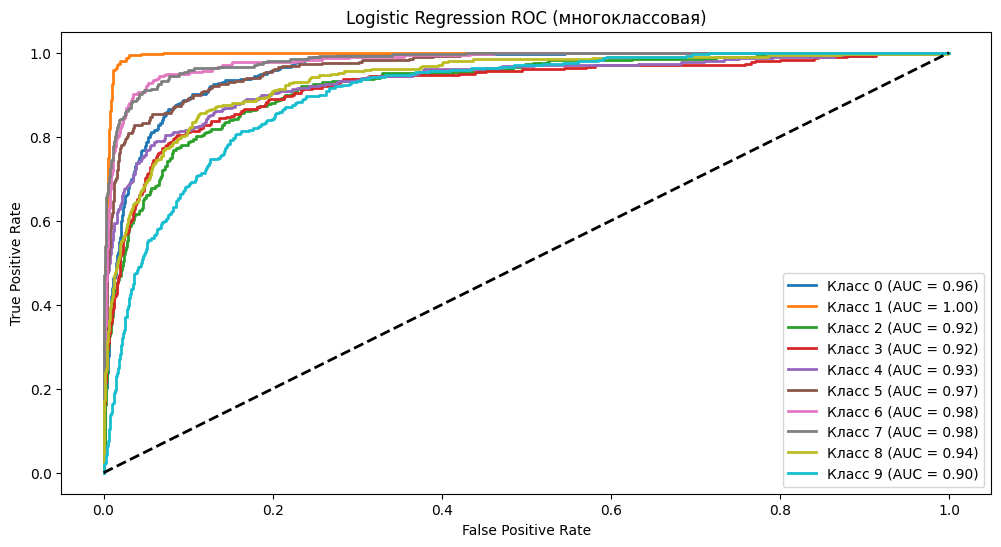


KNN:
Accuracy: 0.89
Precision (macro): 0.89
Recall (macro): 0.89


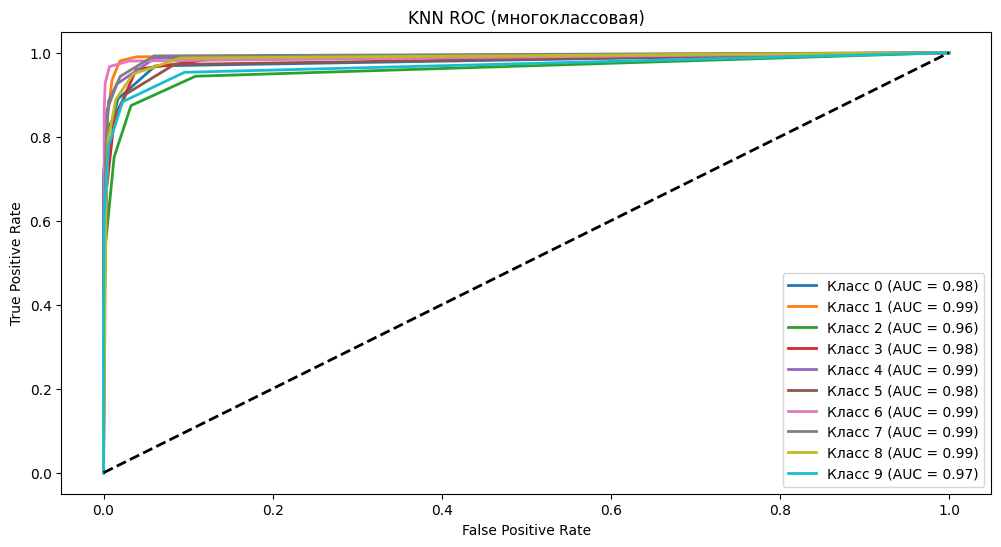


Сравнение моделей:
LogReg Macro-AUC: 0.95
KNN Macro-AUC: 0.98


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Бинаризация меток
y_test_bin = label_binarize(y_test, classes=np.arange(10))

# Метрики для логистической регрессии
print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.2f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_logreg, average='macro'):.2f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_logreg, average='macro'):.2f}")

# ROC-кривая для логистической регрессии
y_pred_prob_logreg = logreg.predict_proba(X_test_scaled)
fpr_logreg = dict()
tpr_logreg = dict()
roc_auc_logreg = dict()
for i in range(10):
    fpr_logreg[i], tpr_logreg[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob_logreg[:, i])
    roc_auc_logreg[i] = auc(fpr_logreg[i], tpr_logreg[i])

# Визуализация
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(fpr_logreg[i], tpr_logreg[i], lw=2, label=f'Класс {i} (AUC = {roc_auc_logreg[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Logistic Regression ROC (многоклассовая)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Метрики для KNN
print("\nKNN:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_knn, average='macro'):.2f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_knn, average='macro'):.2f}")

# ROC-кривая для KNN
y_pred_prob_knn = knn.predict_proba(X_test_scaled)
fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()
for i in range(10):
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob_knn[:, i])
    roc_auc_knn[i] = auc(fpr_knn[i], tpr_knn[i])

# Визуализация
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(fpr_knn[i], tpr_knn[i], lw=2, label=f'Класс {i} (AUC = {roc_auc_knn[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('KNN ROC (многоклассовая)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Сравнение моделей
print("\nСравнение моделей:")
print(f"LogReg Macro-AUC: {np.mean(list(roc_auc_logreg.values())):.2f}")
print(f"KNN Macro-AUC: {np.mean(list(roc_auc_knn.values())):.2f}")